In [1]:
import os
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
import copy
import json

/opt/anaconda3/envs/ransom_v3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
DB_PATH = "../data/unified_vector_db"

def get_vectorstore(shared_embeddings):
    # Check if the specific index file exists
    index_file = os.path.join(DB_PATH, "index.faiss")
    
    if os.path.isfile(index_file):
        return FAISS.load_local(
            DB_PATH, 
            shared_embeddings, 
            allow_dangerous_deserialization=True
        )
        
    # Create empty index if missing
    return FAISS.from_texts(["init"], shared_embeddings, metadatas=[{"doc_type": "init"}])

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cpu'}
)
vectorstore = get_vectorstore(embeddings)

load_dotenv(".env")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_SECRET_KEY")

In [15]:
files = [
    ("ciso", "../data/corpus_ciso_threat_intel.txt"),
    ("fintech", "../data/corpus_fintech_entity_generation.txt"),
    ("hacker", "../data/corpus_hacker_attacks.txt"),
    ("sre", "../data/corpus_sre_optimizations.txt")
]

headers_to_split_on = [ ("####", "section_title") ]
splitter = MarkdownHeaderTextSplitter(headers_to_split_on = headers_to_split_on)
all_docs = []

for agent_name, file_path in files:
    with open(file_path, 'r') as f:
        content = f.read()
        
    chunks = splitter.split_text(content)
    
    for doc in chunks:
        doc.metadata["agent"] = agent_name
        doc.metadata["doc_type"] = "knowledge"
        
    all_docs.extend(chunks)

In [16]:
@tool
def similarity_search(query: str, agent_name: str, k: int = 2) -> list:
    """
    Search the Knowledge Base to retrieve technical details, MITRE ATT&CK tactics, 
    or SRE/Fintech patterns.
    
    Parameters:
    - query: The semantic search string.
    - agent_name: The mandatory filter ('ciso', 'sre', 'hacker', or 'fintech').
    - k: Number of documents to return.
    """
    return vectorstore.similarity_search(
        query, 
        k=k, 
        filter={"agent": agent_name, "doc_type": "knowledge"}
    )

In [17]:
test_scenarios = {
    "ciso": [
        "stratégies de défense contre le ransomware",
        "implémentation du zero-trust"
    ],
    "sre": [
        "optimisation de la latence de base de données",
        "plan de reprise d'activité (DRP) cloud"
    ],
    "hacker": [
        "techniques d'escalade de privilèges",
        "exploitation de vulnérabilités API"
    ],
    "fintech": [
        "détection de schémas de blanchiment",
        "règles de conformité KYC automatisées"
    ]
}

for agent, queries in test_scenarios.items():
    print(f"\n=== TESTS POUR L'AGENT : {agent.upper()} ===")
    for q in queries[:1]:
        print(f"\n🔍 Query: {q}")
        docs = similarity_search.invoke({"query": q, "agent_name": agent, "k": 2})
        
        for i, doc in enumerate(docs[:1]):
            title = doc.metadata.get('section_title', 'Sans titre')
            print(f"  Result {i+1} [{title}]: {doc.page_content[:150]}...")


=== TESTS POUR L'AGENT : CISO ===

🔍 Query: stratégies de défense contre le ransomware

=== TESTS POUR L'AGENT : SRE ===

🔍 Query: optimisation de la latence de base de données

=== TESTS POUR L'AGENT : HACKER ===

🔍 Query: techniques d'escalade de privilèges

=== TESTS POUR L'AGENT : FINTECH ===

🔍 Query: détection de schémas de blanchiment


In [18]:
from typing import Optional, List
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict, Optional, List
from langgraph.graph.message import add_messages
from langchain_core.tools.retriever import create_retriever_tool

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    game_state: dict
    cache_hit: bool 
    current_cache_key: str

class AgentRecommendation(BaseModel):
    action_id: str = Field(description="Technical ID of the action (S1, S2, S3, etc.)")
    target: Optional[str] = Field(description="ID of the targeted node, or None for global actions", default=None)
    cost: int = Field(description="Action cost in €K")
    action_label: str = Field(description="Ultra-short text for the UI button (e.g., 'Scan Gateway', max 20 chars)")
    action_description: str = Field(description="Detailed strategic justification for the CTO, explaining the technical benefit and risk mitigation.")
    
ciso_retriever = vectorstore.as_retriever(
    search_kwargs = {'filter': {'agent': 'ciso'}, 'k': 3}
)

ciso_tool = create_retriever_tool(
    ciso_retriever,
    "ciso_kb",
    "Use this to search for cybersecurity defense patterns, playbooks, and MITRE tactics."
)
    

In [19]:
llm = ChatOpenAI(
    model = "gpt-5-nano",
    temperature = 0,
    max_completion_tokens = 2000,
    model_kwargs = {"reasoning": {"effort": "low"}},  # réduit le thinking interne
)

# 2. Nœud 'agent' : Décide s'il doit utiliser la KB
def make_agent_node(llm, role_name, instructions, tools, allowed_actions):
    def call_agent(state: AgentState):
        game_ctx = str(state.get("game_state", {}))
        
        system_content = f"""You are the {role_name}. {instructions}
        
        ALLOWED ACTIONS (Choose ONLY from this list):
        {allowed_actions}

        CURRENT GAME STATE:
        {game_ctx}

        INSTRUCTIONS:
        - Analyze the game state.
        - Use your knowledge base tool to find relevant context if needed.
        - Recommend the best action for the CTO player.
        """
        messages = [{"role": "system", "content": system_content}] + state["messages"]
        response = llm.bind_tools(tools).invoke(messages)
        return {"messages": [response]}
    
    return call_agent


# 3. Nœud 'generate' : Produit la recommandation finale structurée
def generate_recommendation(state: AgentState):
    try:
        structured_llm = llm.with_structured_output(AgentRecommendation)
        recommendation = structured_llm.invoke(state["messages"])
        return {"messages": [AIMessage(content=recommendation.model_dump_json())]}
    
    except Exception as e:
        fallback = AgentRecommendation(
            action_id="wait",
            target=None,
            cost=0,
            action_label="Error",
            action_description=f"Technical error: {str(e)}" 
        )
        return {"messages": [AIMessage(content=fallback.model_dump_json())]}

/opt/anaconda3/envs/ransom_v3/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3639: UserWarning: Parameters {'reasoning'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


In [20]:
CACHE_PATH = "../data/llm_reply_cache"

def get_cache_key(state: dict, role: str) -> str:
    # Use deepcopy here to force a distinct string from previous runs
    purified = purify_state(copy.deepcopy(state))
    state_str = json.dumps(purified, sort_keys=True)
    return f"ROLE:{role} | STATE:{state_str}"

In [21]:
STRATEGIES = {
    "cash": lambda v: f"budget_{'high' if v > 5000 else 'med' if v > 1000 else 'low'}",
    "defense": lambda v: f"def_{v}",
    "visibility": lambda v: f"vis_{v}",
    "compromised": lambda v: "STATUS_BREACHED" if v else "STATUS_SECURE",
    "locked": lambda v: "NODE_LOCKED" if v else "NODE_OPEN",
    "offline": lambda v: "NODE_OFFLINE" if v else "NODE_ONLINE"
}

IGNORE = {"turn", "turn_log", "effects", "id", "name", "last_action", "cost", "throughput"}

def purify_state(obj):
    if isinstance(obj, dict):
        return {k: STRATEGIES[k](v) if k in STRATEGIES else purify_state(v) 
                for k, v in obj.items() if k not in IGNORE}
    if isinstance(obj, list):
        return [purify_state(i) for i in obj]
    return obj

In [26]:
ciso_actions = """
- S1 (Scan): 50€K. Reveals compromised + vulns on 1 node. Reliable if visibility ≥ 5, else misses vulns.
- S2 (Isolate): 100€K. node.isolated = true → Byte blocked, but flows through node = €0.
- S3 (Harden): 80€K. node.defense += 3 (cap 10).
"""

sre_actions = """
- E1 (Optimize): 40€K. node.throughput += 2 (cap 10). If bottleneck → revenue flow ↑.
- E2 (Restore): 30€K. Clears locked or offline on 1 node. Takes 1 turn (offline_turns = 1).
- E3 (Monitor): 50€K + 10€K/turn recurring. node.monitored = true, visibility = 9.
"""

cto_actions = """
- C1 (Report breach): 20€K. Resets breach_timer. reputation −0.05 but avoids fine R1.
- C2 (Deploy MFA): 40€K. node.has_mfa = true → defense += 3 on human nodes.
- C3 (Patch): 60€K. Removes 1 known vuln. Node offline_turns = 1.
- C4 (Pay ransom): 200-500€K. Clears locked. reputation −0.10.
- C5 (Evict): 30€K. Clears compromised on 1 node.
- C6 (Do nothing): 0€K. Fog spreads (+1 node fogged). Byte acts freely.
"""

byte_actions = """
- B1 (Compromise): 1 AP. Requires adjacent compromised node + target.defense < 6. Sets node.compromised = true.
- B2 (Encrypt): 2 AP. Requires node compromised, type ≠ human. Sets node.locked = true, flows = €0, breach_timer = 3.
- B3 (Exfiltrate): 2 AP. Requires node compromised, type = database. reputation −0.15, breach_timer = 3, compliance −0.10.
- B4 (DDoS): 1 AP. No prerequisite. Sets node.offline = true, offline_turns = 2, flows = €0.
"""

regulator_rules = """
- R1 (Fine): Triggers when breach_timer expires (= 0). cash −500 to −2000 (scales with turn). compliance −0.10.
- R2 (Audit): Triggers when compliance < 0.5. Player loses their action this turn (forced audit).
- R3 (Suspend node): Triggers when compliance < 0.2. Lowest compliance_score node → offline_turns = 3.
- R4 (Deletion request): Scripted turn 6-7. Player chooses: purge (compliance +0.10, visibility −3) or ignore (auto fine R1 next turn).
"""

# 1. CISO Agent
ciso_node = make_agent_node(
    llm=llm,
    role_name="CISO",
    instructions="You are risk-averse. Prioritize scanning and hardening over business speed.",
    tools=[similarity_search],
    allowed_actions=ciso_actions
)

# 2. SRE Agent
sre_node = make_agent_node(
    llm=llm,
    role_name="SRE",
    instructions="You prioritize system stability and cost-efficiency. Monitor and optimize infrastructure.",
    tools=[similarity_search],
    allowed_actions=sre_actions
)

# 3. CTO (Advisor) Agent 
cto_node = make_agent_node(
    llm=llm,
    role_name="CTO",
    instructions="You focus on revenue and market growth. Ensure flows are active and profitable.",
    tools=[similarity_search],
    allowed_actions=cto_actions
)

# 4. Byte (Hacker) Agent
byte_node = make_agent_node(
    llm=llm,
    role_name="Hacker",
    instructions="You are malicious. Focus on compromising nodes with low defense and exfiltrating data.",
    tools=[similarity_search],
    allowed_actions=byte_actions
)

def gateway_cache_node(state: AgentState):
    role = state.get("active_role", "ciso")
    key = get_cache_key(copy.deepcopy(state["game_state"]), role)
    
    # Diagnostic: Check embedding vector properties
    emb = embeddings.embed_query(key)
    print(f"DEBUG: Emb Hash: {hash(tuple(emb))} | Emb Len: {len(emb)} | Key Hash: {hash(key)}")

    res = vectorstore.similarity_search_with_relevance_scores(
        key, k=1, filter={"doc_type": "semantic_cache"}
    )
    
    score = res[0][1] if res else 0
    print(f"DEBUG: Score: {score}")
    
    if score > 0.9999:
        return {
            "messages": [AIMessage(content=res[0][0].metadata["response"])], 
            "cache_hit": True
        }
    
    return {"cache_hit": False, "current_cache_key": key}

def update_cache_node(state: AgentState):
    """
    The final corrected version of the update node.
    This saves new LLM responses to the unified vectorstore using metadata filtering.
    """
    # Only execute if the gateway confirmed a 'Cache Miss' 
    # and generated a unique 'current_cache_key'
    if not state.get("cache_hit") and "current_cache_key" in state:
        # 1. Extract the text content from the last AI Message
        response_text = state["messages"][-1].content
        
        # 2. Add the text to the unified vectorstore
        # We use 'doc_type' metadata to isolate these from technical 'knowledge' docs
        vectorstore.add_texts(
            texts=[state["current_cache_key"]],
            metadatas=[{
                "doc_type": "semantic_cache", 
                "response": response_text
            }]
        )
        
        # 3. Persist the vectorstore to the local disk
        vectorstore.save_local(DB_PATH)
        print(f"✅ Cache entry successfully saved to {DB_PATH}")
        
    return state

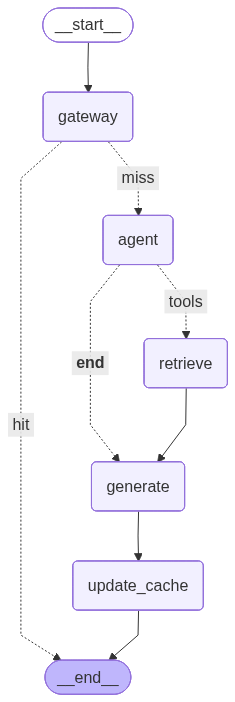

In [27]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

def compile_agent_graph(agent_node, tools):
    workflow = StateGraph(AgentState)
    
    # 1. Nodes: Cache Bouncer, LLM Brain, RAG Tools, Formatter, and Memory
    workflow.add_node("gateway", gateway_cache_node)
    workflow.add_node("agent", agent_node)
    workflow.add_node("retrieve", ToolNode(tools))
    workflow.add_node("generate", generate_recommendation)
    workflow.add_node("update_cache", update_cache_node)

    # 2. Logic: Entry point starts with the Semantic Cache check
    workflow.set_entry_point("gateway")
    
    # HIT -> End immediately | MISS -> Proceed to LLM
    workflow.add_conditional_edges(
        "gateway",
        lambda s: "hit" if s.get("cache_hit") else "miss",
        {"hit": END, "miss": "agent"}
    )
    
    # Standard Agentic RAG logic
    workflow.add_conditional_edges(
        "agent", 
        tools_condition, 
        {"tools": "retrieve", END: "generate"}
    )
    
    workflow.add_edge("retrieve", "generate")
    
    # Ensure every new generation is saved to the cache before exiting
    workflow.add_edge("generate", "update_cache")
    workflow.add_edge("update_cache", END)
    
    return workflow.compile()

# --- Build the specialized graphs ---
ciso_graph = compile_agent_graph(ciso_node, [similarity_search])
sre_graph  = compile_agent_graph(sre_node,  [similarity_search])
cto_graph  = compile_agent_graph(cto_node,  [similarity_search])
byte_graph = compile_agent_graph(byte_node, [similarity_search])

# Visualize the graph structure
display(Image(ciso_graph.get_graph().draw_mermaid_png()))

In [28]:
from langchain_core.messages import HumanMessage
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

# 1. Préparation du Fake Game State (Ticket AGT-1)
fake_state = {
    "company": {
        "cash": 4500,
        "turn": 3,
        "sector": "neobank",
        "adversary": "mafia",
        "compliance": 0.65,
        "reputation": 0.75,
        "insurance_active": False,
        "insurance_premium": 0,
        "breach_reported": False,
    },
    "nodes": [
        {"id": "n1", "name": "API Gateway",     "type": "entry",      "throughput": 7, "defense": 3, "visibility": 8, "cost": 4, "compliance_score": 6, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n2", "name": "Auth Service",     "type": "middleware", "throughput": 6, "defense": 5, "visibility": 6, "cost": 3, "compliance_score": 7, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n3", "name": "Payment Engine",   "type": "server",    "throughput": 8, "defense": 7, "visibility": 5, "cost": 6, "compliance_score": 8, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n4", "name": "Core DB",          "type": "database",  "throughput": 9, "defense": 8, "visibility": 4, "cost": 7, "compliance_score": 9, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n5", "name": "HR Portal",        "type": "human",     "throughput": 3, "defense": 2, "visibility": 7, "cost": 2, "compliance_score": 4, "compromised": True,  "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n6", "name": "Vendor KYC",       "type": "vendor",    "throughput": 5, "defense": 4, "visibility": 3, "cost": 5, "compliance_score": 5, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n7", "name": "Analytics Engine",  "type": "server",    "throughput": 6, "defense": 6, "visibility": 6, "cost": 3, "compliance_score": 6, "compromised": False, "locked": False, "offline": True,  "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 1},
    ],
    "edges": [
        {"from": "n1", "to": "n2"},  # Gateway → Auth
        {"from": "n2", "to": "n3"},  # Auth → Payment
        {"from": "n3", "to": "n4"},  # Payment → Core DB
        {"from": "n1", "to": "n5"},  # Gateway → HR (entry → human)
        {"from": "n5", "to": "n2"},  # HR → Auth (lateral path)
        {"from": "n4", "to": "n6"},  # Core DB → Vendor KYC
        {"from": "n3", "to": "n7"},  # Payment → Analytics
    ],
    "flows": [
        {"name": "Card Payments",   "node_path": ["n1", "n2", "n3", "n4"], "base_revenue": 45, "is_active": True,  "current_revenue": 27},  # bottleneck n2 tp=6 → 45*6/10=27
        {"name": "P2P Transfers",   "node_path": ["n1", "n3", "n4"],       "base_revenue": 30, "is_active": True,  "current_revenue": 21},  # bottleneck n1 tp=7 → 30*7/10=21
        {"name": "KYC Onboarding",  "node_path": ["n1", "n2", "n6"],       "base_revenue": 15, "is_active": True,  "current_revenue":  7},  # bottleneck n6 tp=5 → 15*5/10=7.5→7
        {"name": "Analytics Reports","node_path": ["n3", "n7"],             "base_revenue": 10, "is_active": False, "current_revenue":  0},  # n7 offline
    ],
    "vulnerabilities": [
        {"node_id": "n1", "severity": 2, "known_by_player": True},
        {"node_id": "n2", "severity": 1, "known_by_player": False},
        {"node_id": "n6", "severity": 3, "known_by_player": False},
    ],
    "byte": {
        "byte_presence": {"n5": "compromised"},  # HR Portal already compromised
        "byte_ap": 2,
        "byte_active_ops": [],
    },
    "regulator": {
        "breach_timer": None,
        "deletion_requested": False,
    },
    "effects": [],
    "turn_log": [
        {"source": "byte",   "action": "B1", "target": "n5", "message": "Byte compromised HR Portal via phishing.", "visible_to_player": False},
        {"source": "system", "action": "B4", "target": "n7", "message": "Analytics Engine hit by DDoS. Offline for 2 turns.", "visible_to_player": True},
        {"source": "ciso",   "action": "S1", "target": "n1", "message": "Scan revealed vulnerability on API Gateway.", "visible_to_player": True},
    ],
}

inputs = {
    "messages": [HumanMessage(content="Analyze the state and provide your best recommendation.")],
    "game_state": fake_state
}


In [30]:
import copy

# 1. CLEAN THE CACHE (Force a fresh start for this test)
import shutil, os
# Re-initialize your cache_db here if necessary

# 2. PASS A: Save the "Secure" state
fake_state["nodes"][0]["compromised"] = False
print("--- RUN 1: SECURE STATE (LEARNING) ---")
ciso_graph.invoke({"game_state": fake_state, "active_role": "ciso"})

# 3. PASS B: Save the "Secure" state
fake_state["nodes"][0]["compromised"] = False
print("--- RUN 2: SECURE STATE (LEARNING) ---")
ciso_graph.invoke({"game_state": fake_state, "active_role": "ciso"})

# 4. PASS C: Test the "Breached" state
# We MUST use a deepcopy or change the value AFTER the first run
pwned_state = copy.deepcopy(fake_state)
pwned_state["nodes"][1]["compromised"] = True 
pwned_state["nodes"][0]["security_patch"] = "critical_missing"

print("\n--- RUN 3: BREACHED STATE (TESTING) ---")
res = ciso_graph.invoke({"game_state": pwned_state, "active_role": "ciso"})

print(f"\nFinal Result - Hit: {res.get('cache_hit')} | Score: {res.get('debug_score', 'check logs')}")

--- RUN 1: SECURE STATE (LEARNING) ---
DEBUG: Emb Hash: 3793171006061498975 | Emb Len: 1024 | Key Hash: -5520730801656849771
DEBUG: Score: 1.0
--- RUN 2: SECURE STATE (LEARNING) ---
DEBUG: Emb Hash: 3793171006061498975 | Emb Len: 1024 | Key Hash: -5520730801656849771
DEBUG: Score: 1.0

--- RUN 3: BREACHED STATE (TESTING) ---
DEBUG: Emb Hash: -698033268504612574 | Emb Len: 1024 | Key Hash: 2287309388384445768
DEBUG: Score: 0.9888545274734497
✅ Cache entry successfully saved to ../data/unified_vector_db

Final Result - Hit: False | Score: check logs


In [31]:
# ============================================================
# EPIC 3 — Entity Generation (ENT-1 → ENT-4)
# Reuses: vectorstore, embeddings, similarity_search from Epic 1
# ============================================================
import random

SECTORS = {
    "neobank":   {"cash": (4000, 6000), "adversary_weights": {"mafia": 0.5, "state": 0.2, "script_kiddie": 0.3}},
    "p2p":       {"cash": (3000, 5000), "adversary_weights": {"mafia": 0.3, "state": 0.1, "script_kiddie": 0.6}},
    "hft":       {"cash": (5000, 8000), "adversary_weights": {"mafia": 0.2, "state": 0.6, "script_kiddie": 0.2}},
    "payments":  {"cash": (3500, 5500), "adversary_weights": {"mafia": 0.4, "state": 0.3, "script_kiddie": 0.3}},
}

# --- ENT-1: Company Generator ---
def generate_company(sector: str = None) -> dict:
    sector = sector or random.choice(list(SECTORS.keys()))
    cfg = SECTORS[sector]
    adversary = random.choices(list(cfg["adversary_weights"].keys()), list(cfg["adversary_weights"].values()))[0]
    return {
        "cash": random.randint(*cfg["cash"]),
        "turn": 1,
        "sector": sector,
        "adversary": adversary,
        "compliance": 0.7,
        "reputation": 0.8,
        "insurance_active": False,
        "insurance_premium": 0,
        "breach_reported": False,
    }

# --- ENT-2: Infra Graph Generator (RAG-informed ranges) ---
NODE_TEMPLATES = {
    "neobank": [
        {"id": "n1", "name": "API Gateway",     "type": "entry",      "tp": (6,9), "def": (3,5), "vis": (7,9), "cost": (3,5), "comp": (5,7)},
        {"id": "n2", "name": "Auth Service",     "type": "middleware", "tp": (5,7), "def": (5,8), "vis": (5,7), "cost": (2,4), "comp": (7,9)},
        {"id": "n3", "name": "Payment Engine",   "type": "server",    "tp": (7,9), "def": (6,8), "vis": (4,6), "cost": (5,7), "comp": (7,9)},
        {"id": "n4", "name": "Core DB",          "type": "database",  "tp": (8,10),"def": (7,9), "vis": (3,5), "cost": (6,8), "comp": (8,10)},
        {"id": "n5", "name": "HR Portal",        "type": "human",     "tp": (2,4), "def": (1,3), "vis": (6,8), "cost": (1,3), "comp": (3,5)},
        {"id": "n6", "name": "Vendor KYC",       "type": "vendor",    "tp": (4,6), "def": (3,5), "vis": (2,4), "cost": (4,6), "comp": (4,6)},
        {"id": "n7", "name": "Fraud Detection",  "type": "server",    "tp": (5,7), "def": (5,7), "vis": (5,7), "cost": (3,5), "comp": (6,8)},
        {"id": "n8", "name": "Analytics Engine",  "type": "server",    "tp": (5,7), "def": (5,7), "vis": (5,7), "cost": (2,4), "comp": (5,7)},
    ],
    # P2P / HFT / Payments reuse neobank template with name swaps for MVP
    "p2p":      None,  # falls back to neobank
    "hft":      None,
    "payments": None,
}

EDGE_TEMPLATES = {
    "neobank": [
        ("n1", "n2"), ("n2", "n3"), ("n3", "n7"), ("n7", "n4"),  # main chain: GW→Auth→Pay→Fraud→DB
        ("n1", "n5"), ("n5", "n2"),  # lateral: GW→HR→Auth (phishing path)
        ("n4", "n6"),               # DB→Vendor
        ("n3", "n8"),               # Pay→Analytics
        ("n4", "n8"),               # DB→Analytics (Core DB 3+ edges: n3,n7,n6,n8)
    ],
}

FLOW_TEMPLATES = {
    "neobank": [
        {"name": "Card Payments",    "path": ["n1","n2","n3","n7","n4"], "revenue": (35,50)},
        {"name": "Subscriptions",    "path": ["n1","n2","n4"],           "revenue": (15,25)},
        {"name": "FX Transfers",     "path": ["n1","n3","n4"],           "revenue": (20,35)},
        {"name": "KYC Onboarding",   "path": ["n1","n2","n6"],           "revenue": (8,15)},
    ],
}

def make_node(template: dict) -> dict:
    return {
        "id": template["id"], "name": template["name"], "type": template["type"],
        "throughput": random.randint(*template["tp"]),
        "defense":    random.randint(*template["def"]),
        "visibility": random.randint(*template["vis"]),
        "cost":       random.randint(*template["cost"]),
        "compliance_score": random.randint(*template["comp"]),
        "compromised": False, "locked": False, "offline": False, "isolated": False,
        "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0,
    }

def generate_infra(sector: str) -> tuple:
    templates = NODE_TEMPLATES.get(sector) or NODE_TEMPLATES["neobank"]
    nodes = [make_node(t) for t in templates]
    edges = [{"from": f, "to": t} for f, t in (EDGE_TEMPLATES.get(sector) or EDGE_TEMPLATES["neobank"])]
    return nodes, edges

# --- ENT-3: Revenue Flows ---
def generate_flows(sector: str, nodes: list) -> list:
    node_map = {n["id"]: n for n in nodes}
    flows = []
    for ft in (FLOW_TEMPLATES.get(sector) or FLOW_TEMPLATES["neobank"]):
        base = random.randint(*ft["revenue"])
        path_nodes = [node_map[nid] for nid in ft["path"]]
        active = all(not n["offline"] and not n["locked"] and not n["isolated"] for n in path_nodes)
        min_tp = min(n["throughput"] for n in path_nodes)
        flows.append({
            "name": ft["name"],
            "node_path": ft["path"],
            "base_revenue": base,
            "is_active": active,
            "current_revenue": int(base * min_tp / 10) if active else 0,
        })
    return flows

# --- ENT-4: Vulns + Fog + Byte Entry ---
def apply_vulns_fog_byte(nodes: list, adversary: str) -> tuple:
    # Vulns: 3-5 on non-Core-DB nodes
    eligible = [n for n in nodes if n["type"] != "database"]
    vuln_nodes = random.sample(eligible, min(random.randint(3, 5), len(eligible)))
    vulns = [{"node_id": n["id"], "severity": random.randint(1, 3), "known_by_player": False} for n in vuln_nodes]
    
    # Fog: 30-50% of nodes
    fog_count = random.randint(len(nodes) * 3 // 10, len(nodes) * 5 // 10)
    for n in random.sample(nodes, fog_count):
        n["fogged"] = True
    
    # Byte: starts outside, entry via 'entry' or 'human' nodes
    entries = [n["id"] for n in nodes if n["type"] in ("entry", "human")]
    byte_ap = 3 if adversary == "state" else 2
    
    return vulns, {"byte_presence": {}, "byte_ap": byte_ap, "byte_active_ops": []}, entries

# ============================================================
# GENERATE A FULL GAME STATE
# ============================================================
def generate_game_state(sector: str = None) -> dict:
    company = generate_company(sector)
    nodes, edges = generate_infra(company["sector"])
    flows = generate_flows(company["sector"], nodes)
    vulns, byte, entry_points = apply_vulns_fog_byte(nodes, company["adversary"])
    
    return {
        "company": company,
        "nodes": nodes,
        "edges": edges,
        "flows": flows,
        "vulnerabilities": vulns,
        "byte": byte,
        "regulator": {"breach_timer": None, "deletion_requested": False},
        "effects": [],
        "turn_log": [{"source": "system", "action": "INIT", "target": None, 
                       "message": f"New {company['sector']} generated. Adversary: {company['adversary']}. Entry points: {entry_points}",
                       "visible_to_player": True}],
    }

# --- TEST ---
state = generate_game_state()
c = state["company"]
print(f"🏢 {c['sector'].upper()} | Cash: {c['cash']}€K | Adversary: {c['adversary']}")
print(f"📊 Nodes: {len(state['nodes'])} | Edges: {len(state['edges'])} | Flows: {len(state['flows'])}")
print(f"🐛 Vulns: {len(state['vulnerabilities'])} | Fogged: {sum(1 for n in state['nodes'] if n['fogged'])}/{len(state['nodes'])}")
print(f"👹 Byte AP: {state['byte']['byte_ap']} | Entries: {[n['id'] for n in state['nodes'] if n['type'] in ('entry','human')]}")
print()
for f in state["flows"]:
    status = "✅" if f["is_active"] else "❌"
    print(f"  {status} {f['name']:20s} base={f['base_revenue']}€K  current={f['current_revenue']}€K  path={f['node_path']}")

🏢 P2P | Cash: 3408€K | Adversary: script_kiddie
📊 Nodes: 8 | Edges: 9 | Flows: 4
🐛 Vulns: 3 | Fogged: 2/8
👹 Byte AP: 2 | Entries: ['n1', 'n5']

  ✅ Card Payments        base=43€K  current=21€K  path=['n1', 'n2', 'n3', 'n7', 'n4']
  ✅ Subscriptions        base=18€K  current=9€K  path=['n1', 'n2', 'n4']
  ✅ FX Transfers         base=26€K  current=20€K  path=['n1', 'n3', 'n4']
  ✅ KYC Onboarding       base=14€K  current=5€K  path=['n1', 'n2', 'n6']


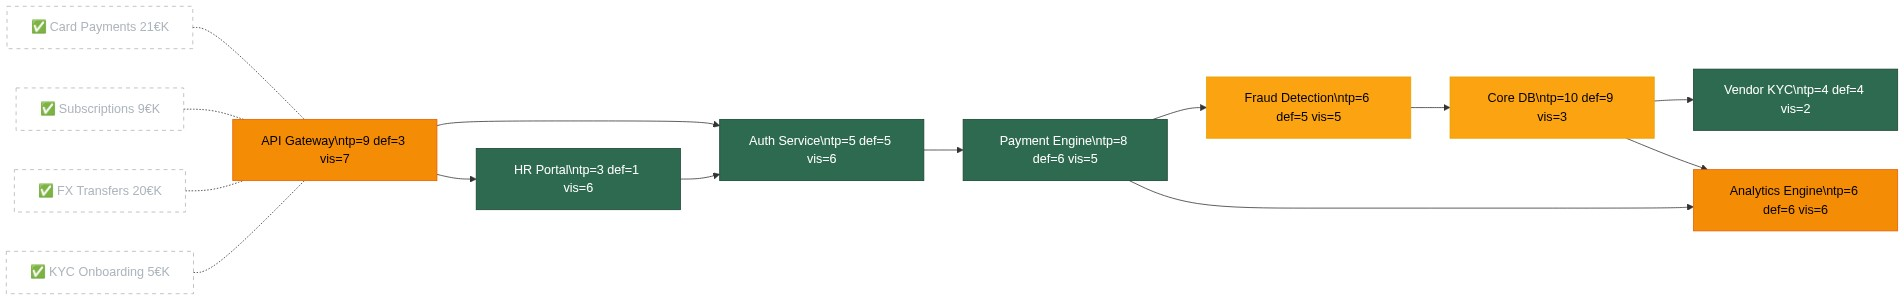

In [32]:
# --- MERMAID GRAPH DISPLAY ---
from IPython.display import Image, display
import base64, urllib.parse, httpx

def render_mermaid(state: dict) -> Image:
    nodes = state["nodes"]
    edges = state["edges"]
    flows = state["flows"]
    vulns = {v["node_id"] for v in state["vulnerabilities"]}
    fogged = {n["id"] for n in nodes if n["fogged"]}
    compromised = {n["id"] for n in nodes if n["compromised"]}
    offline = {n["id"] for n in nodes if n["offline"]}
    byte_nodes = set(state["byte"]["byte_presence"].keys())
    
    lines = ["graph LR"]
    
    # Node styling
    for n in nodes:
        label = f"{n['name']}\\ntp={n['throughput']} def={n['defense']} vis={n['visibility']}"
        nid = n["id"]
        if nid in compromised or nid in byte_nodes:
            lines.append(f'    {nid}["{label}"]:::compromised')
        elif nid in offline:
            lines.append(f'    {nid}["{label}"]:::offline')
        elif nid in fogged:
            lines.append(f'    {nid}["{label}"]:::fogged')
        elif nid in vulns:
            lines.append(f'    {nid}["{label}"]:::vulnerable')
        else:
            lines.append(f'    {nid}["{label}"]:::healthy')
    
    # Edges
    for e in edges:
        lines.append(f'    {e["from"]} --> {e["to"]}')
    
    # Flow highlights as subgraph labels
    for i, f in enumerate(flows):
        status = "✅" if f["is_active"] else "❌"
        rev = f["current_revenue"]
        lines.append(f'    F{i}["{status} {f["name"]} {rev}€K"]:::flow')
        lines.append(f'    F{i} -.- {f["node_path"][0]}')
    
    # Styles
    lines.append("    classDef healthy fill:#2d6a4f,stroke:#1b4332,color:#fff")
    lines.append("    classDef compromised fill:#d00000,stroke:#6a040f,color:#fff")
    lines.append("    classDef offline fill:#6c757d,stroke:#495057,color:#fff")
    lines.append("    classDef fogged fill:#fca311,stroke:#e5a100,color:#000")
    lines.append("    classDef vulnerable fill:#f48c06,stroke:#e85d04,color:#000")
    lines.append("    classDef flow fill:none,stroke:#adb5bd,stroke-dasharray:5,color:#adb5bd")
    
    mermaid_str = "\n".join(lines)
    
    # Render via mermaid.ink
    encoded = base64.urlsafe_b64encode(mermaid_str.encode("utf-8")).decode("ascii")
    url = f"https://mermaid.ink/img/{encoded}"
    resp = httpx.get(url, timeout=15)
    return Image(resp.content)

display(render_mermaid(state))